In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv("shopnow_sales.csv")

In [5]:
df.head()

,OrderID,CustomerID,OrderDate,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,Region
0,1001,C001,2024-01-05,Laptop,Lenovo ThinkPad,1,900,900,Tarjeta,Norte
1,1002,C002,2024-01-06,Smartphone,iPhone 13,2,799,1598,PayPal,Sur
2,1003,C003,2024-01-07,Accesorios,Mouse Logitech,3,25,75,Tarjeta,Oeste
3,1004,C004,2024-01-08,Laptop,Dell XPS 13,1,1100,1100,Transferencia,Este
4,1005,C002,2024-01-09,Accesorios,Teclado Mecánico,1,80,80,Tarjeta,Sur


In [6]:
df.isnull().sum()

OrderID            0
CustomerID         0
OrderDate          0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
Region             0
dtype: int64

In [7]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
dtype: bool

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.duplicated(subset='OrderID')]

,OrderID,CustomerID,OrderDate,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,Region


In [10]:
df["flag"]=df["TotalAmount"] == (df["Quantity"] * df["UnitPrice"])

In [11]:
df.head()

,OrderID,CustomerID,OrderDate,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,Region,flag
0,1001,C001,2024-01-05,Laptop,Lenovo ThinkPad,1,900,900,Tarjeta,Norte,True
1,1002,C002,2024-01-06,Smartphone,iPhone 13,2,799,1598,PayPal,Sur,True
2,1003,C003,2024-01-07,Accesorios,Mouse Logitech,3,25,75,Tarjeta,Oeste,True
3,1004,C004,2024-01-08,Laptop,Dell XPS 13,1,1100,1100,Transferencia,Este,True
4,1005,C002,2024-01-09,Accesorios,Teclado Mecánico,1,80,80,Tarjeta,Sur,True


In [12]:
df["OrderDate"]= pd.to_datetime(df["OrderDate"])

In [13]:
df["year"]=df["OrderDate"].dt.year
df["month"]= df["OrderDate"].dt.month_name()

In [14]:
df.groupby("month")["TotalAmount"].sum().sort_values(ascending=False)

month
January     3753
March       2929
February    2400
Name: TotalAmount, dtype: int64

In [23]:
df.groupby("Region")["TotalAmount"].sum().sort_values(ascending=False)

Region
Norte    3330
Sur      2838
Este     1800
Oeste    1114
Name: TotalAmount, dtype: int64

In [16]:
df.groupby("CustomerID")["TotalAmount"].mean().sort_values(ascending=False)

CustomerID
C004    1100.0
C012    1100.0
C001     900.0
C002     839.0
C010     799.0
C005     750.0
C008     700.0
C007     650.0
C006     240.0
C013      80.0
C003      75.0
C009      60.0
C011      50.0
Name: TotalAmount, dtype: float64

In [17]:
df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False)

PaymentMethod
Tarjeta          8
PayPal           4
Transferencia    3
Name: OrderID, dtype: int64

In [18]:
df.groupby("Region")["OrderID"].count().sort_values(ascending=False)

Region
Norte    5
Sur      4
Este     3
Oeste    3
Name: OrderID, dtype: int64

Text(0.5, 1.0, 'Sales per Category')

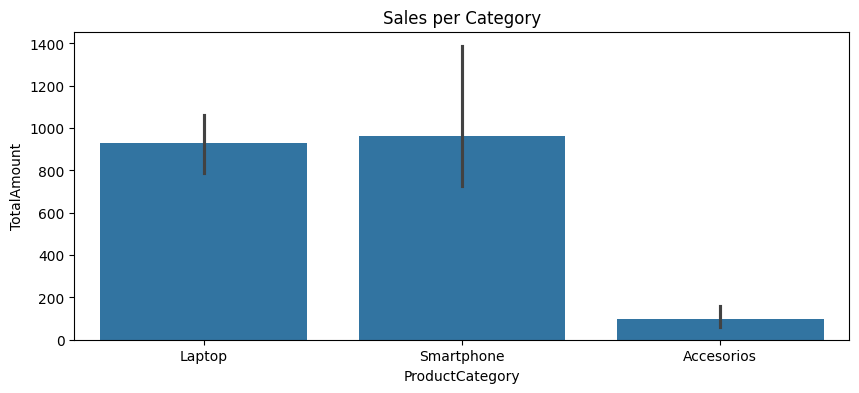

In [19]:
plt.figure(figsize=(10,4))
sns.barplot(x="ProductCategory", y="TotalAmount", data=df)
plt.title("Sales per Category")

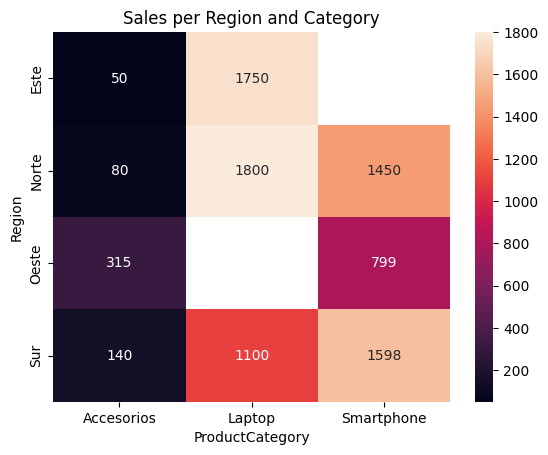

In [20]:
heatmap_data=df.pivot_table(values="TotalAmount",index="Region",columns="ProductCategory",aggfunc="sum")
sns.heatmap(heatmap_data,annot=True, fmt=".0f")
plt.title("Sales per Region and Category")
plt.show()


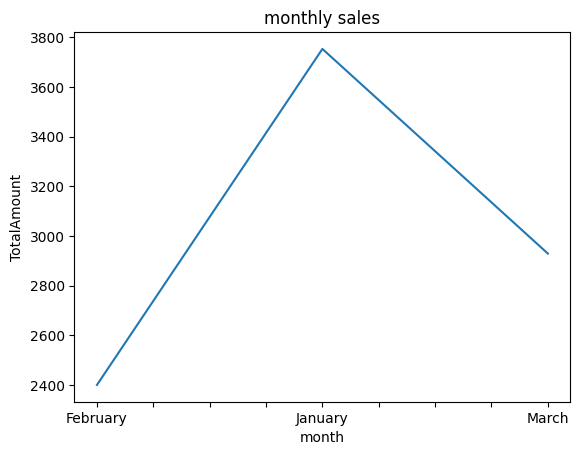

In [21]:
serie= df.groupby("month")["TotalAmount"].sum()
serie.plot(kind="line")
plt.title("monthly sales")
plt.xlabel("month")
plt.ylabel("TotalAmount")
plt.show()

In [22]:
df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)

ProductName
iPhone 13             2397
Dell XPS 13           2200
Lenovo ThinkPad       1800
Samsung Galaxy S22     750
Google Pixel 7         700
HP Pavilion            650
Auriculares Sony       240
Teclado Mecánico       160
Mouse Logitech         125
Webcam Logitech         60
Name: TotalAmount, dtype: int64